In [ ]:
import seaborn as sns
import pandas as pd

df = sns.load_dataset('diamonds')
print(df.head())
print(df.dtypes)
print(df.shape)


   carat      cut color clarity  depth  table  price     x     y     z
0   0.23    Ideal     E     SI2   61.5   55.0    326  3.95  3.98  2.43
1   0.21  Premium     E     SI1   59.8   61.0    326  3.89  3.84  2.31
2   0.23     Good     E     VS1   56.9   65.0    327  4.05  4.07  2.31
3   0.29  Premium     I     VS2   62.4   58.0    334  4.20  4.23  2.63
4   0.31     Good     J     SI2   63.3   58.0    335  4.34  4.35  2.75
carat       float64
cut        category
color      category
clarity    category
depth       float64
table       float64
price         int64
x           float64
y           float64
z           float64
dtype: object
(53940, 10)


In [ ]:
# checking for null values
null_counts = df.isnull().sum() #isnull counts each cell and marks it true or false (misssing or not). .sum() adds up all trues per column giving a count.
null_percent = (df.isnull().sum() / df.shape[0]) * 100
print(null_counts)
print(null_percent)

carat      0
cut        0
color      0
clarity    0
depth      0
table      0
price      0
x          0
y          0
z          0
dtype: int64
carat      0.0
cut        0.0
color      0.0
clarity    0.0
depth      0.0
table      0.0
price      0.0
x          0.0
y          0.0
z          0.0
dtype: float64


In [ ]:
# Duplicate Detection
duplicate_count = df.duplicated().sum() # dupplicated() checks each row and marks it true if its an exact copy of earlier row.
print("number of duplicated rows:", duplicate_count)

df = df.drop_duplicates() #removes those duplicated rows, keeping only the 1st occurrence of each.
print("Shape after removing duplicates:", df.shape)

number of duplicated rows: 146
Shape after removing duplicates: (53794, 10)


In [ ]:
null_percent_after = (df.isnull().sum() / df.shape[0]) * 100
print(null_percent_after)

carat      0.0
cut        0.0
color      0.0
clarity    0.0
depth      0.0
table      0.0
price      0.0
x          0.0
y          0.0
z          0.0
dtype: float64


In [ ]:
# t-4 --> Data type correction.
print("Memory usage BEFORE any changes:")
print(df.memory_usage(deep=True))
print("Total:", df.memory_usage(deep=True).sum())

Memory usage BEFORE any changes:
Index      430352
carat      430352
cut         54240
color       54444
clarity     54510
depth      430352
table      430352
price      430352
x          430352
y          430352
z          430352
dtype: int64
Total: 3606010


In [ ]:
df['cut'] = df['cut'].astype('object')
print("Memory usage with 'cut' as object dtype:")
print(df.memory_usage(deep=True))
print("Total:", df.memory_usage(deep=True).sum())

Memory usage with 'cut' as object dtype:
Index       430352
carat       430352
cut        2974159
color        54444
clarity      54510
depth       430352
table       430352
price       430352
x           430352
y           430352
z           430352
dtype: int64
Total: 6525929


In [ ]:
df['cut'] = df['cut'].astype('category')
print("Memory usage with 'cut' as category dtype:")
print(df.memory_usage(deep=True))
print("Total:", df.memory_usage(deep=True).sum())

Memory usage with 'cut' as category dtype:
Index      430352
carat      430352
cut         54240
color       54444
clarity     54510
depth      430352
table      430352
price      430352
x          430352
y          430352
z          430352
dtype: int64
Total: 3606010


In [ ]:
# t-5 --> descriptive stastics and skewness
numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns # automatically grabs only the numeric columns( carats,depth,table,x,y,z), so you dont have to type them out manually and risk missing one.
print("Numeric columns:", list(numeric_cols))
print(df[numeric_cols].describe()) # gives you count, mean, std, min, 25%, 50%, 75% percentiles, and max for every numeric columns in one shot. this is your baseline statistical summary.
print("\nSkewness of each numeric columns:")
skew_values = df[numeric_cols].skew() # computes the skewness of the columns. if its o-> roughly symmetic, >0--> most values are low/clustered, but few are very high pull the tail out. <0--> most values are high, but very few are low values pull out the tail.
print(skew_values)
print("\nColumn with highest absolute skewness:")
print(skew_values.abs().sort_values(ascending=False))


Numeric columns: ['carat', 'depth', 'table', 'price', 'x', 'y', 'z']
             carat         depth         table         price             x  \
count  53794.00000  53794.000000  53794.000000  53794.000000  53794.000000   
mean       0.79778     61.748080     57.458109   3933.065082      5.731214   
std        0.47339      1.429909      2.233679   3988.114460      1.120695   
min        0.20000     43.000000     43.000000    326.000000      0.000000   
25%        0.40000     61.000000     56.000000    951.000000      4.710000   
50%        0.70000     61.800000     57.000000   2401.000000      5.700000   
75%        1.04000     62.500000     59.000000   5326.750000      6.540000   
max        5.01000     79.000000     95.000000  18823.000000     10.740000   

                  y             z  
count  53794.000000  53794.000000  
mean       5.734653      3.538714  
std        1.141209      0.705037  
min        0.000000      0.000000  
25%        4.720000      2.910000  
50%        5

In [ ]:
# task- 6 --> outlier detection with IQR
# this is where we investigate those y values.
# q1 = value below which 25%of data falls. q3 = value below with 75% of data falls.
# IQR = capture middle 50% of the data ignoring extremes.
# lower/upper bound = stn statistical rule anything outside this range is flagged as a statistical outlier.
for col in ['y', 'carat']: # for loop repeats the same calculation for both columns without copy-pasting the block twice.
  q1 = df[col].quantile(0.25)
  q3 = df[col].quantile(0.75)
  IQR = q3 - q1
  lower_bound = q1 - 1.5 * IQR
  upper_bound = q3 + 1.5 * IQR

  outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]

  print(f"col")
  print(f"q1: {q1}, q3:{q3}, IQR: {IQR}")
  print(f"Lower bound: {lower_bound}, Upper bound: {upper_bound}")
  print(f"Number of outliers: {outliers.shape[0]}")
  print()

col
q1: 4.72, q3:6.54, IQR: 1.8200000000000003
Lower bound: 1.9899999999999993, Upper bound: 9.27
Number of outliers: 28

col
q1: 0.4, q3:1.04, IQR: 0.64
Lower bound: -0.5599999999999999, Upper bound: 2.0
Number of outliers: 1873



In [ ]:
y_outliers = df[(df['y'] < 1.99) | (df['y'] > 9.27)]
print(y_outliers[['carat', 'y', 'price']]. sort_values('y'))

       carat      y  price
11963   1.00   0.00   5139
15951   1.14   0.00   6381
26243   1.20   0.00  15686
24520   1.56   0.00  12800
49556   0.71   0.00   2130
27429   2.25   0.00  18034
22831   3.00   9.31  10863
27514   3.01   9.31  18242
27685   3.01   9.32  18710
26431   3.40   9.34  15964
25460   3.01   9.37  14220
27649   3.01   9.38  18593
22741   3.01   9.38  10761
24131   3.24   9.40  12300
24297   3.22   9.42  12545
27638   3.04   9.46  18559
23644   3.65   9.48  11668
24328   3.50   9.59  12587
27679   3.51   9.63  18701
26534   3.67   9.81  16193
27130   4.13   9.85  17329
26444   4.00   9.94  15984
25999   4.01   9.94  15223
25998   4.01  10.10  15223
27630   4.50  10.16  18531
27415   5.01  10.54  18018
49189   0.51  31.80   2075
24067   2.00  58.90  12210


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

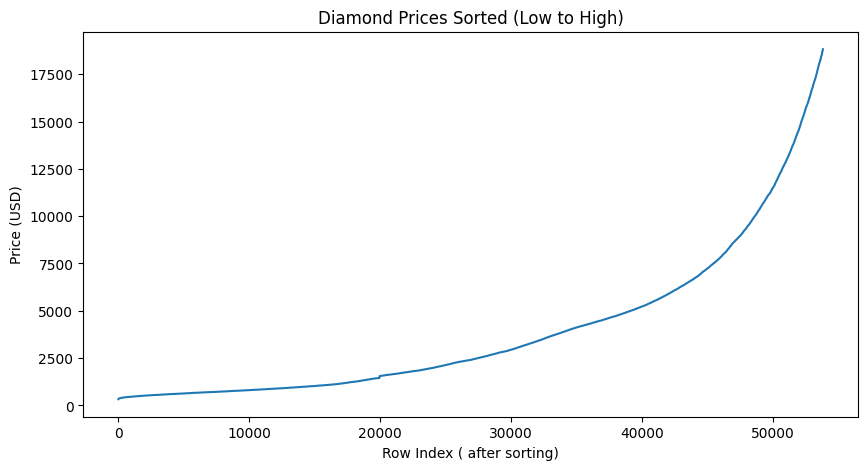

In [ ]:
plt.figure(figsize=(10,5)) # (10,5) --> is the width and height of canvas . figure --> creates a blank canvas.
plt.plot(df['price'].sort_values().values) # sort-values()--> is a pandas method that sorts the particular column in ascending order. .values() --> converts the sorted series in numpy array.
plt.title('Diamond Prices Sorted (Low to High)')
plt.xlabel('Row Index ( after sorting)')
plt.ylabel('Price (USD)')
plt.show()

/tmp/ipykernel_1614/3953116559.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('cut')['price'].mean().plot.bar()


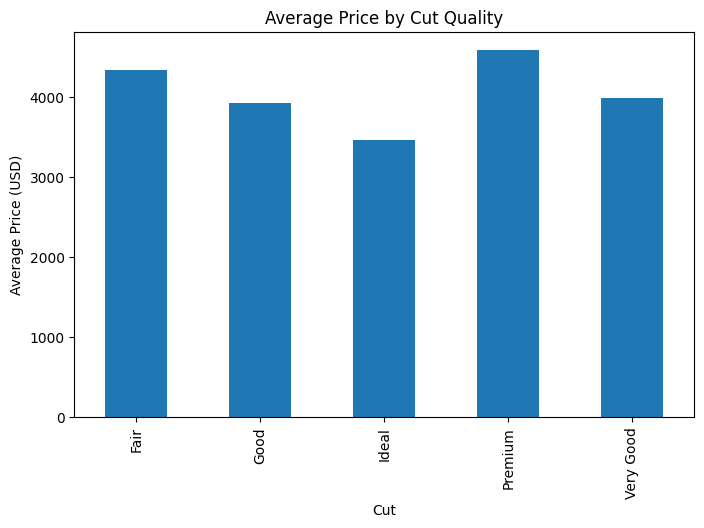

In [ ]:
# Bar plot (mean of a numeric column across categories of a categorical column).
plt.figure(figsize=(8,5))
df.groupby('cut')['price'].mean().plot.bar()
plt.title('Average Price by Cut Quality')
plt.xlabel('Cut')
plt.ylabel('Average Price (USD)')
plt.show()

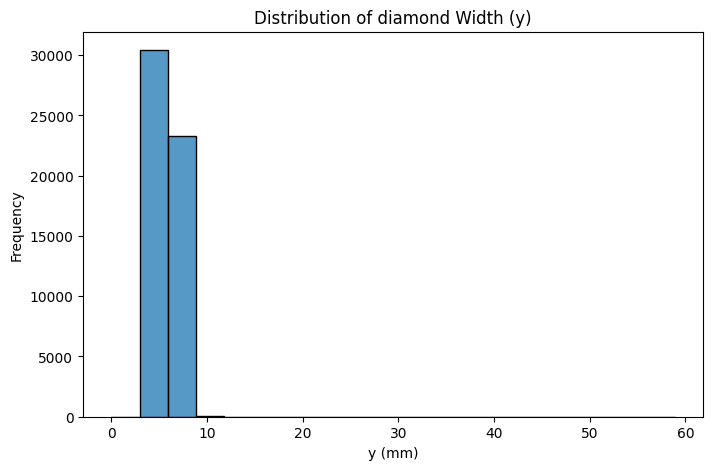

In [ ]:
# Histogram
plt.figure(figsize=(8,5))
sns.histplot(df['y'], bins=20)
plt.title('Distribution of diamond Width (y)')
plt.xlabel('y (mm)')
plt.ylabel('Frequency')
plt.show()

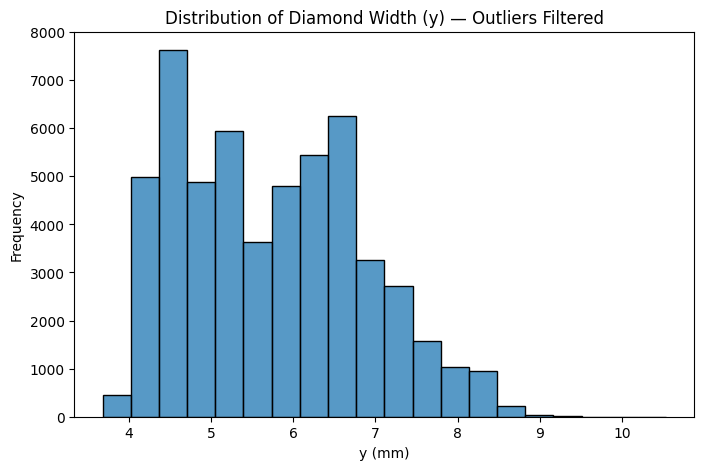

In [ ]:
plt.figure(figsize=(8,5))
sns.histplot(df[(df['y'] > 0) & (df['y'] < 15)]['y'], bins=20)
plt.title('Distribution of Diamond Width (y) — Outliers Filtered')
plt.xlabel('y (mm)')
plt.ylabel('Frequency')
plt.show()

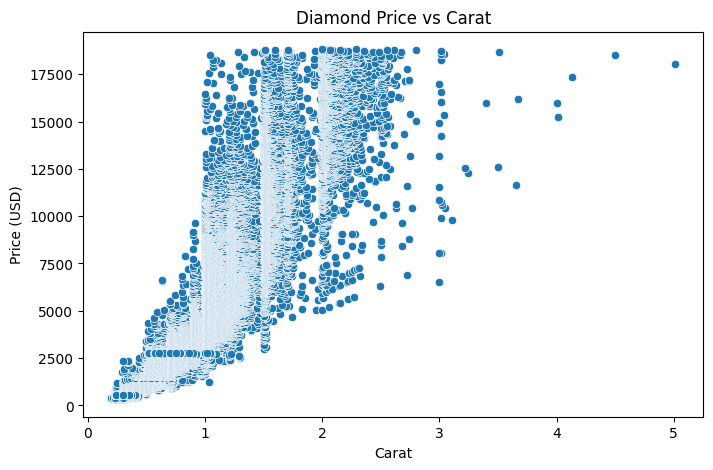

In [ ]:
#scatterplot
plt.figure(figsize=(8,5))
sns.scatterplot(x=df['carat'], y=df['price'])
plt.title('Diamond Price vs Carat')
plt.xlabel('Carat')
plt.ylabel('Price (USD)')
plt.show()

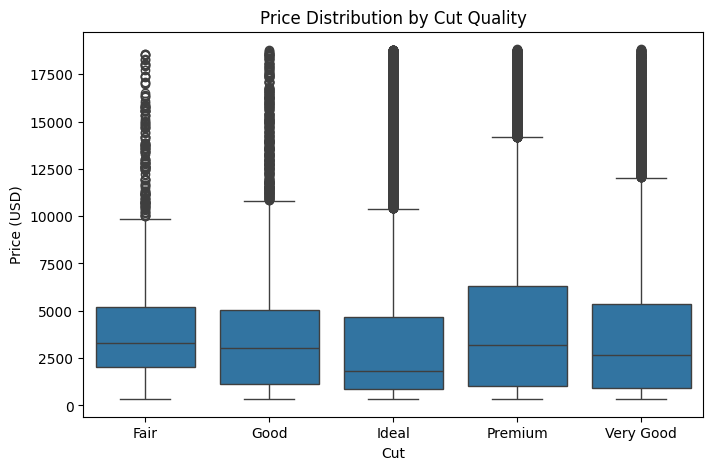

In [ ]:
#box plot ( numeric column split y categorical column)
plt.figure(figsize=(8,5))
sns.boxplot(x=df['cut'], y=df['price'])
plt.title('Price Distribution by Cut Quality')
plt.xlabel('Cut')
plt.ylabel('Price (USD)')
plt.show()

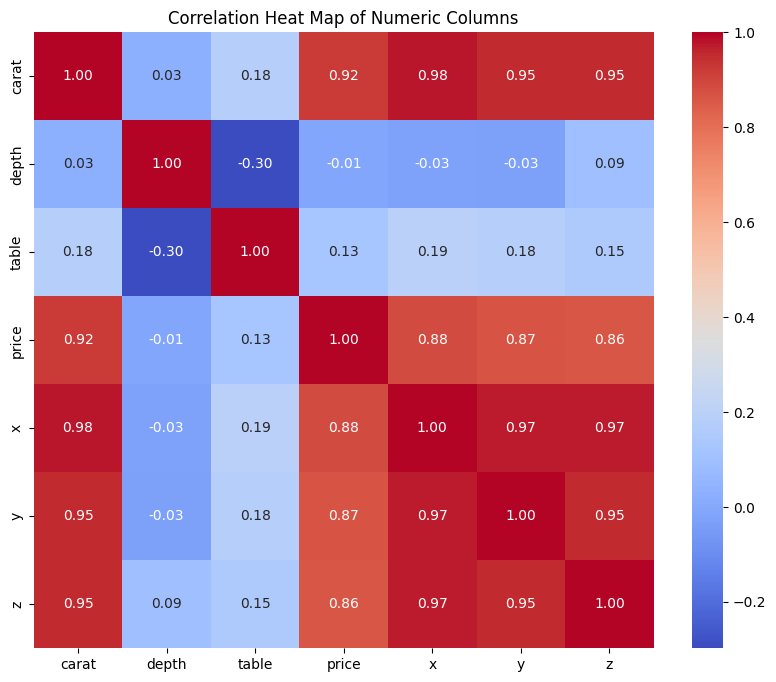

In [ ]:
#corelation heatmap
plt.figure(figsize=(10,8))
corr_matrix = df[numeric_cols].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heat Map of Numeric Columns')
plt.show()

In [ ]:
# 9a:- Imputation strategy comparison.(mean vs median)

for col in ['y', 'price']:
  col_mean = df[col].mean()
  col_median = df[col].median()
  print(f"{col}")
  print(f"mean: {col_mean}")
  print(f"median: {col_median}")
  print()


y
mean: 5.734653307060266
median: 5.71

price
mean: 3933.065081607614
median: 2401.0



In [ ]:
for col in ['y', 'price']:
  df[col] = df[col].fillna(df[col].median())

print(df[['y', 'price']].isnull().sum())

y        0
price    0
dtype: int64


In [ ]:
# 9b:- spearman Rank correlation --> instead of using raw values, Spearman first converts every value in a column to its rank (1st smallest, 2nd smallest, 3rd smallest, etc.), then computes correlation on those ranks. This means Spearman only cares about whether values move together consistently (monotonic relationship) — it doesn't care if the relationship is a straight line or a curve, unlike Pearson which is sensitive to the exact linear shape.
pearson_corr = df[numeric_cols].corr(method = 'pearson')
spearman_corr = df[numeric_cols].corr(method = 'spearman')
print("pearson correlation matrix:")
print(pearson_corr)
print("\nSpearson correlation matrix:")
print(spearman_corr)

pearson correlation matrix:
          carat     depth     table     price         x         y         z
carat  1.000000  0.027861  0.181091  0.921548  0.975380  0.951908  0.953542
depth  0.027861  1.000000 -0.297669 -0.011048 -0.025348 -0.029389  0.094757
table  0.181091 -0.297669  1.000000  0.126566  0.194855  0.183231  0.150270
price  0.921548 -0.011048  0.126566  1.000000  0.884504  0.865395  0.861208
x      0.975380 -0.025348  0.194855  0.884504  1.000000  0.974592  0.970686
y      0.951908 -0.029389  0.183231  0.865395  0.974592  1.000000  0.951844
z      0.953542  0.094757  0.150270  0.861208  0.970686  0.951844  1.000000

Spearson correlation matrix:
          carat     depth     table     price         x         y         z
carat  1.000000  0.030288  0.194166  0.962924  0.996161  0.995614  0.993255
depth  0.030288  1.000000 -0.245194  0.010181 -0.023273 -0.025247  0.103651
table  0.194166 -0.245194  1.000000  0.171025  0.201466  0.194952  0.159105
price  0.962924  0.010181  0.1

In [ ]:
# compute the difference table to find the 3 pairs where spearman and pearson disagree the most
diff = (spearman_corr - pearson_corr).abs()
print("Absolute difference | Spearman - pearson| :")
print(diff)

Absolute difference | Spearman - pearson| :
          carat     depth     table     price         x         y         z
carat  0.000000  0.002427  0.013075  0.041375  0.020782  0.043706  0.039713
depth  0.002427  0.000000  0.052475  0.021229  0.002075  0.004142  0.008894
table  0.013075  0.052475  0.000000  0.044459  0.006611  0.011721  0.008834
price  0.041375  0.021229  0.044459  0.000000  0.078756  0.097393  0.096102
x      0.020782  0.002075  0.006611  0.078756  0.000000  0.023300  0.016680
y      0.043706  0.004142  0.011721  0.097393  0.023300  0.000000  0.035237
z      0.039713  0.008894  0.008834  0.096102  0.016680  0.035237  0.000000


In [ ]:
pairs = [('price', 'x'), ('price', 'y'),('price', 'z')]

for a, b in pairs:
  print(f"{a} vs {b}: Pearson = {pearson_corr.loc[a,b]:.4f}, Spearman= {spearman_corr.loc[a,b]:.4f}, Diff = {diff.loc[a,b]:.4f}")

price vs x: Pearson = 0.8845, Spearman= 0.9633, Diff = 0.0788
price vs y: Pearson = 0.8654, Spearman= 0.9628, Diff = 0.0974
price vs z: Pearson = 0.8612, Spearman= 0.9573, Diff = 0.0961


In [28]:
# 9c --> grouped Aggregation
grouped_stats = df.groupby('cut')['price'].agg(['mean','std','count'])
print(grouped_stats)

                  mean          std  count
cut                                       
Fair       4341.954318  3540.118138   1598
Good       3919.121039  3671.070930   4891
Ideal      3462.749953  3810.926394  21488
Premium    4583.501891  4348.052680  13748
Very Good  3981.016157  3934.813175  12069


/tmp/ipykernel_1614/2917405478.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_stats = df.groupby('cut')['price'].agg(['mean','std','count'])


In [31]:
ratio = grouped_stats['mean'].max() / grouped_stats['mean'].min()
print("Ratio of the highest to lowest group mean:", ratio)

Ratio of the highest to lowest group mean: 1.3236595055329181


In [32]:
print(grouped_stats)

                  mean          std  count
cut                                       
Fair       4341.954318  3540.118138   1598
Good       3919.121039  3671.070930   4891
Ideal      3462.749953  3810.926394  21488
Premium    4583.501891  4348.052680  13748
Very Good  3981.016157  3934.813175  12069


In [34]:
df.to_csv('cleaned_data.csv', index=False)

In [35]:
df_raw = sns.load_dataset('diamonds')
df_raw.to_csv('diamond_raw.csv', index=False)